In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

In [9]:
russian_stop_words = [
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 
    'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 
    'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 
    'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 
    'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 
    'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 
    'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 
    'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 
    'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 
    'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впрочем', 'хорошо', 'свою', 'этой', 
    'перед', 'иногда', 'лучше', 'чуть', 'том', 'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 
    'между'
]

In [10]:
data = {
    'post_id': list(range(1, 22)),  # 21 элемент
    'title': [
        'Изучение Python для начинающих',
        'Продвинутый Python: асинхронное программирование',
        'Data Science с Python и Pandas',
        'Веб-разработка на Django',
        'Автоматизация задач на Python',
        
        # Программирование (C++ и другие языки)
        'Программирование на C++ с нуля',
        'Изучение C++ для game development',
        'Java для enterprise приложений',
        'JavaScript и фронтенд разработка',
        'Go язык для высоконагруженных систем',
        
        # Спорт (футбол)
        'Футбол для любителей',
        'Футбольные тренировки для продвинутых',
        'Тактика и стратегия в футболе',
        'Футзал в закрытом помещении',
        'Футбольный клуб для ветеранов',
        
        # Спорт (баскетбол и другие)
        'Баскетбол для новичков',
        'Уличный баскетбол 3x3',
        'Волейбол на пляже',
        'Теннис для всех возрастов',
        'Плавание и аквааэробика',
        'Йога и медитация'
    ],
    'description': [
        # Python
        'Основы программирования на Python для начинающих, простые проекты',
        'Изучаем асинхронность в Python, asyncio и продвинутые темы',
        'Анализ данных с помощью Python, библиотеки Pandas и NumPy',
        'Создание веб-приложений на Django framework',
        'Автоматизация рутинных задач с помощью скриптов на Python',
        
        # Другие языки программирования
        'Изучение C++ с основ: указатели, классы, ООП',
        'Разработка игр на C++ и Unreal Engine',
        'Корпоративные приложения на Java Spring Boot',
        'Современный JavaScript, React и фронтенд разработка',
        'Высокопроизводительные системы на языке Go',
        
        # Футбол
        'Регулярные футбольные матчи для любителей любого уровня',
        'Интенсивные тренировки по футболу для опытных игроков',
        'Изучение футбольной тактики и игровых стратегий',
        'Футзал в спортивном зале, мини-футбол',
        'Футбол для игроков старшего возраста, щадящие тренировки',
        
        # Другие виды спорта
        'Обучение баскетболу с основными правилами и техникой',
        'Уличный баскетбол в формате 3 на 3, турниры',
        'Пляжный волейбол на берегу, летний спорт',
        'Большой теннис для начинающих и продолжающих',
        'Занятия плаванием и аквааэробикой в бассейне',
        'Йога для расслабления и медитация для снятия стресса'
    ],
    'category': [
        # Программирование
        'Программирование', 'Программирование', 'Программирование', 'Программирование', 'Программирование',
        'Программирование', 'Программирование', 'Программирование', 'Программирование', 'Программирование',
        
        # Спорт
        'Спорт', 'Спорт', 'Спорт', 'Спорт', 'Спорт',
        'Спорт', 'Спорт', 'Спорт', 'Спорт', 'Спорт', 'Спорт'  # 21 элемент
    ],
    'subcategory': [
        # Программирование
        'Python', 'Python', 'Python', 'Python', 'Python',
        'C++', 'C++', 'Java', 'JavaScript', 'Go',
        
        # Спорт
        'Футбол', 'Футбол', 'Футбол', 'Футбол', 'Футбол',
        'Баскетбол', 'Баскетбол', 'Волейбол', 'Теннис', 'Плавание', 'Йога' # 21 элемент
    ],
    'location': [
        'Онлайн', 'Онлайн', 'Онлайн', 'Онлайн', 'Онлайн',
        'Онлайн', 'Онлайн', 'Онлайн', 'Онлайн', 'Онлайн',
        'Москва', 'Москва', 'Москва', 'Москва', 'Москва',
        'Москва', 'Москва', 'Санкт-Петербург', 'Москва', 'Москва', 'Онлайн'  # 21 элемент
    ]
}

In [11]:
posts_df = pd.DataFrame(data)

In [18]:
posts_df.head()

,post_id,title,description,category,subcategory,location
0,1,Изучение Python для начинающих,Основы программирования на Python для начинающ...,Программирование,Python,Онлайн
1,2,Продвинутый Python: асинхронное программирование,"Изучаем асинхронность в Python, asyncio и прод...",Программирование,Python,Онлайн
2,3,Data Science с Python и Pandas,"Анализ данных с помощью Python, библиотеки Pan...",Программирование,Python,Онлайн
3,4,Веб-разработка на Django,Создание веб-приложений на Django framework,Программирование,Python,Онлайн
4,5,Автоматизация задач на Python,Автоматизация рутинных задач с помощью скрипто...,Программирование,Python,Онлайн


In [12]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words=russian_stop_words,
    ngram_range=(1, 2),
    min_df=1,
    max_features=100
)
tfidf_matrix = tfidf_vectorizer.fit_transform(posts_df['description'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [13]:
def get_recommendations(post_id, cosine_sim, posts_df, n_recommendations=5):
    idx = posts_df.index[posts_df['post_id'] == post_id].tolist()[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n_recommendations+1] 
    post_indices = [i[0] for i in sim_scores]
    
    recommendations = posts_df.iloc[post_indices].copy()
    recommendations['similarity_score'] = [sim_scores[i][1] for i in range(len(sim_scores))]
    
    return recommendations[['post_id', 'title', 'subcategory', 'similarity_score']]

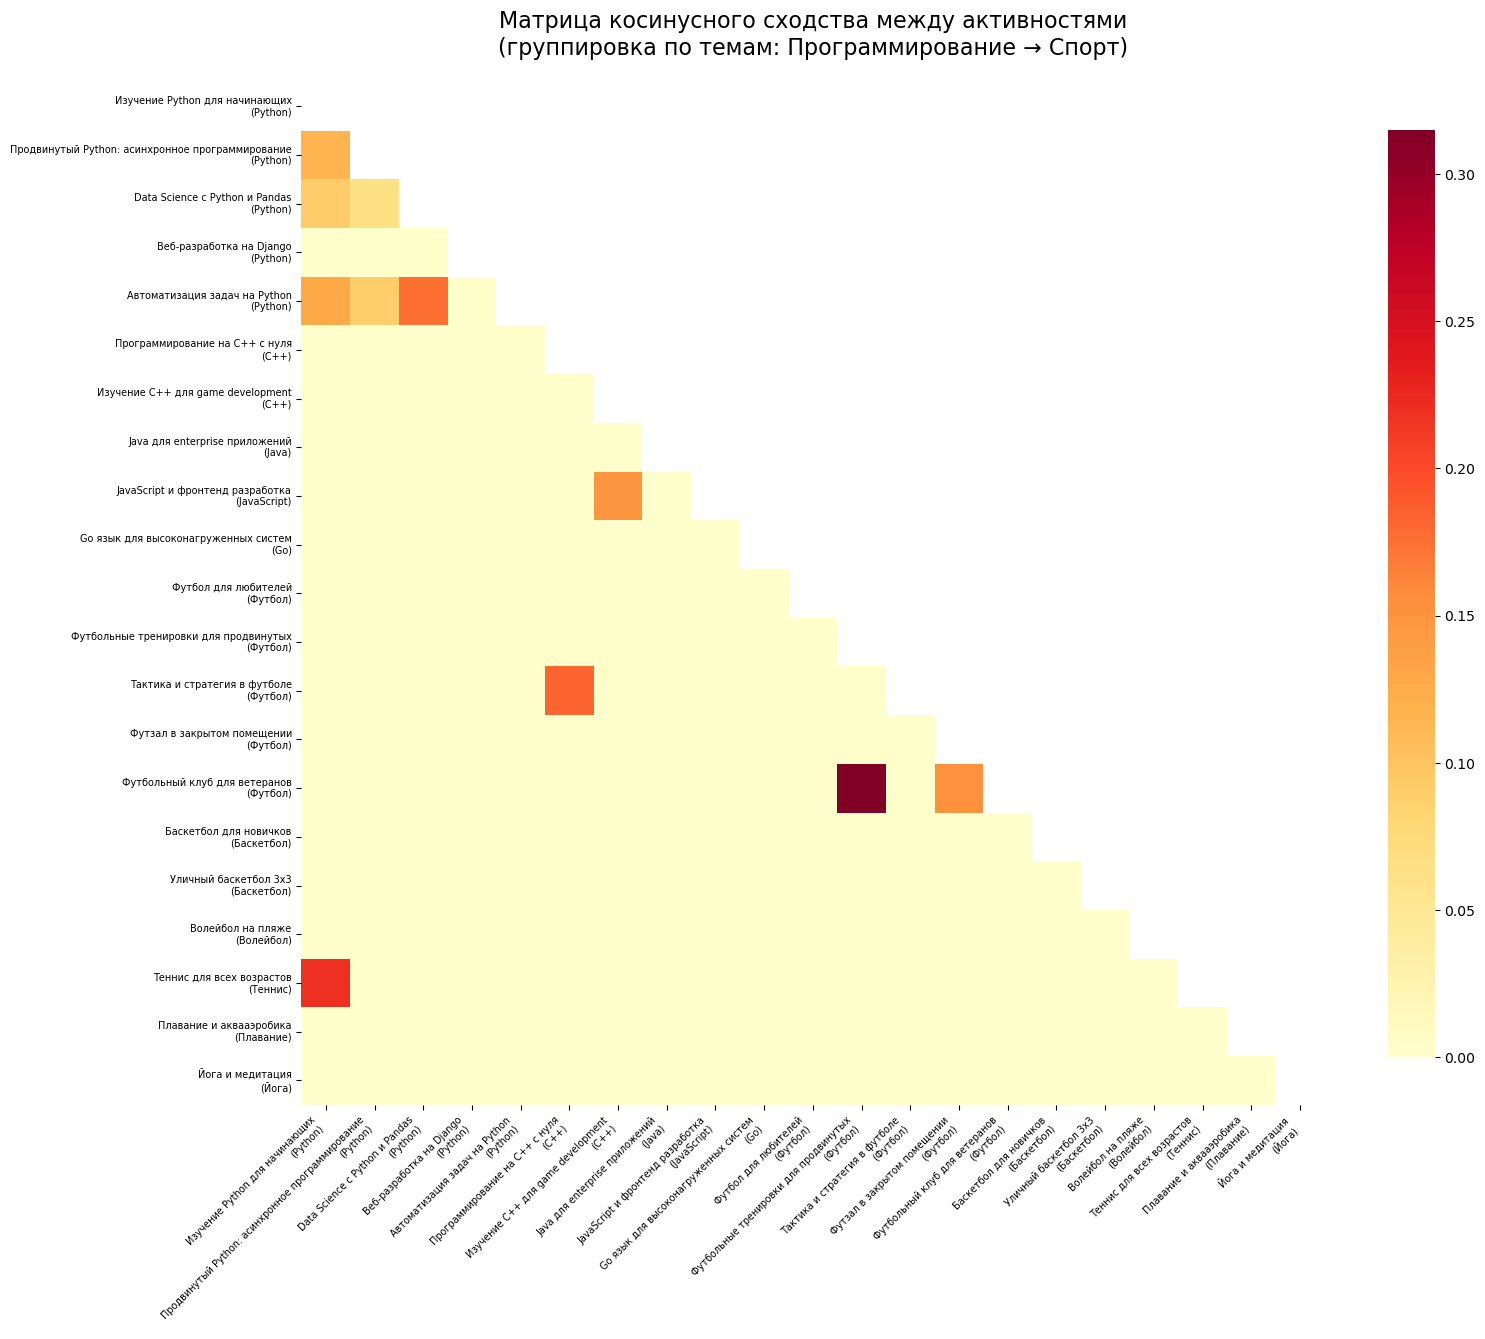

In [14]:
# Визуализация матрицы сходства
plt.figure(figsize=(16, 14))

# Создаем красивую тепловую карту
mask = np.triu(np.ones_like(cosine_sim, dtype=bool))  # Маска для верхнего треугольника

# Создаем подписи с категориями для лучшей читаемости
labels = [f"{title}\n({cat})" for title, cat in zip(posts_df['title'], posts_df['subcategory'])]

sns.heatmap(cosine_sim, 
            mask=mask,
            cmap='YlOrRd',
            square=True,
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'shrink': 0.8})

plt.title('Матрица косинусного сходства между активностями\n(группировка по темам: Программирование → Спорт)', 
          fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [15]:
# Демонстрация работы рекомендательной системы
print("=" * 80)
print("ДЕМОНСТРАЦИЯ РАБОТЫ РЕКОМЕНДАТЕЛЬНОЙ СИСТЕМЫ")
print("=" * 80)

# Тестовые случаи
test_cases = [
    (1, "Python для начинающих → другие Python темы"),
    (6, "C++ → другие языки программирования"),
    (11, "Футбол → другие спортивные активности"),
    (16, "Баскетбол → командные виды спорта")
]

for post_id, description in test_cases:
    post_title = posts_df[posts_df['post_id'] == post_id]['title'].values[0]
    post_subcat = posts_df[posts_df['post_id'] == post_id]['subcategory'].values[0]
    print(f"\n📌 Рекомендации для: '{post_title}' ({post_subcat})")
    print(f"   ({description})")
    print("-" * 60)
    
    recommendations = get_recommendations(post_id, cosine_sim, posts_df)
    
    for _, rec in recommendations.iterrows():
        similarity_percent = rec['similarity_score'] * 100
        print(f"   • {rec['title']} ({rec['subcategory']}) - сходство: {similarity_percent:.1f}%")

ДЕМОНСТРАЦИЯ РАБОТЫ РЕКОМЕНДАТЕЛЬНОЙ СИСТЕМЫ

📌 Рекомендации для: 'Изучение Python для начинающих' (Python)
   (Python для начинающих → другие Python темы)
------------------------------------------------------------
   • Теннис для всех возрастов (Теннис) - сходство: 21.9%
   • Автоматизация задач на Python (Python) - сходство: 12.7%
   • Продвинутый Python: асинхронное программирование (Python) - сходство: 11.5%
   • Data Science с Python и Pandas (Python) - сходство: 9.1%
   • Веб-разработка на Django (Python) - сходство: 0.0%

📌 Рекомендации для: 'Программирование на C++ с нуля' (C++)
   (C++ → другие языки программирования)
------------------------------------------------------------
   • Тактика и стратегия в футболе (Футбол) - сходство: 18.3%
   • Изучение Python для начинающих (Python) - сходство: 0.0%
   • Продвинутый Python: асинхронное программирование (Python) - сходство: 0.0%
   • Data Science с Python и Pandas (Python) - сходство: 0.0%
   • Веб-разработка на Django (Pytho

In [16]:
# Анализ группировки
print("\n" + "=" * 80)
print("АНАЛИЗ ГРУППИРОВКИ АКТИВНОСТЕЙ")
print("=" * 80)

# Показываем среднее сходство внутри групп
groups = {
    'Python программирование': [1, 2, 3, 4, 5],
    'Другие языки программирования': [6, 7, 8, 9, 10],
    'Футбол': [11, 12, 13, 14, 15],
    'Другие виды спорта': [16, 17, 18, 19, 20, 21]
}

for group_name, post_ids in groups.items():
    indices = [posts_df.index[posts_df['post_id'] == pid].tolist()[0] for pid in post_ids]
    group_similarity = cosine_sim[np.ix_(indices, indices)]
    avg_similarity = np.mean(group_similarity)
    
    print(f"\n🏷️  {group_name}:")
    print(f"   Среднее сходство внутри группы: {avg_similarity:.3f}")
    print(f"   Активности: {', '.join([posts_df[posts_df['post_id'] == pid]['subcategory'].values[0] for pid in post_ids])}")


АНАЛИЗ ГРУППИРОВКИ АКТИВНОСТЕЙ

🏷️  Python программирование:
   Среднее сходство внутри группы: 0.253
   Активности: Python, Python, Python, Python, Python

🏷️  Другие языки программирования:
   Среднее сходство внутри группы: 0.212
   Активности: C++, C++, Java, JavaScript, Go

🏷️  Футбол:
   Среднее сходство внутри группы: 0.238
   Активности: Футбол, Футбол, Футбол, Футбол, Футбол

🏷️  Другие виды спорта:
   Среднее сходство внутри группы: 0.167
   Активности: Баскетбол, Баскетбол, Волейбол, Теннис, Плавание, Йога


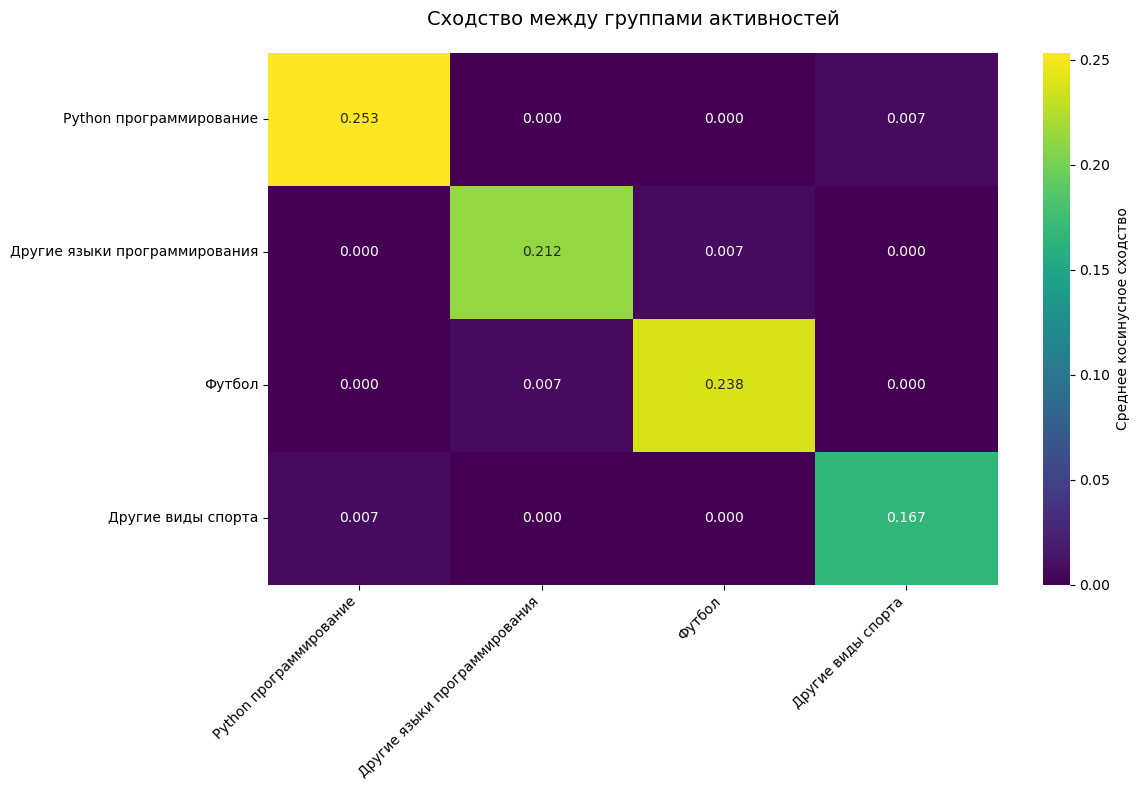

In [17]:
# Визуализация сходства между группами
plt.figure(figsize=(12, 8))

group_labels = list(groups.keys())
group_means = []

for i, (group1_name, group1_ids) in enumerate(groups.items()):
    group1_indices = [posts_df.index[posts_df['post_id'] == pid].tolist()[0] for pid in group1_ids]
    row_means = []
    
    for j, (group2_name, group2_ids) in enumerate(groups.items()):
        group2_indices = [posts_df.index[posts_df['post_id'] == pid].tolist()[0] for pid in group2_ids]
        inter_similarity = cosine_sim[np.ix_(group1_indices, group2_indices)]
        row_means.append(np.mean(inter_similarity))
    
    group_means.append(row_means)

group_means = np.array(group_means)

sns.heatmap(group_means, 
            annot=True, 
            fmt='.3f',
            cmap='viridis',
            xticklabels=group_labels,
            yticklabels=group_labels,
            cbar_kws={'label': 'Среднее косинусное сходство'})

plt.title('Сходство между группами активностей', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Дополнительная визуализация: топ ключевых слов для каждой группы
print("\n" + "=" * 80)
print("КЛЮЧЕВЫЕ СЛОВА ДЛЯ КАЖДОЙ ГРУППЫ")
print("=" * 80)

feature_names = tfidf_vectorizer.get_feature_names_out()

for group_name, post_ids in groups.items():
    indices = [posts_df.index[posts_df['post_id'] == pid].tolist()[0] for pid in post_ids]
    group_tfidf = tfidf_matrix[indices].mean(axis=0)
    
    # Получаем топ-5 терминов для группы
    top_indices = np.array(group_tfidf).flatten().argsort()[-5:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    
    print(f"\n🔑 {group_name}:")
    print(f"   Ключевые слова: {', '.join(top_terms)}")


КЛЮЧЕВЫЕ СЛОВА ДЛЯ КАЖДОЙ ГРУППЫ

🔑 Python программирование:
   Ключевые слова: python, помощью, python начинающих, начинающих простые, начинающих

🔑 Другие языки программирования:
   Ключевые слова: разработка, go, высокопроизводительные системы, высокопроизводительные, классы

🔑 Футбол:
   Ключевые слова: тренировки, игроков, футбол, изучение футбольной, игровых стратегий

🔑 Другие виды спорта:
   Ключевые слова: баскетбол, баскетбол формате, начинающих продолжающих, большой, большой теннис
